In [60]:
import numpy as np
time_series1=np.load("E:/ADHD200/ICA_times_series_941.npy",allow_pickle=True)
label= np.load("E:/ADHD200/label_941.npy")
time_series2=np.load("E:/ADHD200/dict_learning_times_series_941.npy",allow_pickle=True)
label= np.load("E:/ADHD200/label_941.npy")
time_series = []
for i in range(len(time_series1)):
   time_series.append(np.concatenate((time_series1[i], time_series2[i]), axis=1))

In [61]:
from nilearn.connectome import ConnectivityMeasure
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrices = correlation_measure.fit_transform( time_series)
X= correlation_matrices 

In [ ]:
Y=label
X=np.array(X)

# Graph spectral

In [103]:
X=np.load("E:/ADHD_EXP/unni/upsampled_ICA+DL_threshold_0.1178_power_8.npy")
Y=np.load("E:/ADHD_EXP/unni/upsampled_labels_1168.npy")

In [ ]:
X.shape

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from keras.models import Sequential, Model
from keras.layers import Dense, Conv1D, LSTM, Flatten, concatenate

n_samples = X.shape[0]
a = X.shape[1]  # Dimension of the connectivity matrices
n_classes = 2

flattened_matrices = X.reshape(n_samples, -1)
target = Y

# Define CNN model
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(a*a, 1)),
    Flatten(),
    Dense(64, activation='relu')
])

# Define LSTM model
lstm_model = Sequential([
    LSTM(32, input_shape=(a*a, 1)),
    Dense(64, activation='relu')
])

# Combined input
combined_input = concatenate([cnn_model.output, lstm_model.output])

# Classification layer
output = Dense(n_classes, activation='softmax')(combined_input)

# Combined model
combined_model = Model(inputs=[cnn_model.input, lstm_model.input], outputs=output)

# Compile model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Perform 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for train_index, test_index in skf.split(flattened_matrices, target):
    X_train, X_test = flattened_matrices[train_index], flattened_matrices[test_index]
    y_train, y_test = target[train_index], target[test_index]

    # Train model
    history = combined_model.fit([X_train, X_train], y_train, epochs=10, batch_size=32, verbose=0)
    
    # Evaluate model on training data
    train_loss, train_accuracy = combined_model.evaluate([X_train, X_train], y_train, verbose=0)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Evaluate model on test data
    test_loss, test_accuracy = combined_model.evaluate([X_test, X_test], y_test, verbose=0)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print("Train Accuracy:", train_accuracy, "Train Loss:", train_loss)
    print("Test Accuracy:", test_accuracy, "Test Loss:", test_loss)

# Calculate average metrics
avg_train_loss = np.mean(train_losses)
avg_train_accuracy = np.mean(train_accuracies)
avg_test_loss = np.mean(test_losses)
avg_test_accuracy = np.mean(test_accuracies)

print("Average Train Accuracy:", avg_train_accuracy, "Average Train Loss:", avg_train_loss)
print("Average Test Accuracy:", avg_test_accuracy, "Average Test Loss:", avg_test_loss)


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from keras.models import Sequential, Model
from keras.layers import Dense, Conv1D, LSTM, Flatten, concatenate

n_samples = X.shape[0]
a = X.shape[1]  # Dimension of the connectivity matrices
n_classes = 2

flattened_matrices = X.reshape(n_samples, -1)
target = Y

# Define CNN model
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(a*a, 1)),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(128, activation='relu')
])

# Define LSTM model
lstm_model = Sequential([
    LSTM(32, input_shape=(a*a, 1)),
    Dense(128, activation='relu')
])

# Combined input
combined_input = concatenate([cnn_model.output, lstm_model.output])

# Classification layer
output = Dense(n_classes, activation='softmax')(combined_input)

# Combined model
combined_model = Model(inputs=[cnn_model.input, lstm_model.input], outputs=output)

combined_model.summary()
# Compile model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Perform 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for fold, (train_index, test_index) in enumerate(skf.split(flattened_matrices, target)):
    print(f"Fold {fold + 1}/{skf.get_n_splits()}:")

    X_train, X_test = flattened_matrices[train_index], flattened_matrices[test_index]
    y_train, y_test = target[train_index], target[test_index]

    # Reset model weights for each fold
    combined_model.reset_states()

    # Train model
    history = combined_model.fit([X_train, X_train], y_train, epochs=10, batch_size=28, verbose=0, validation_data=([X_test, X_test], y_test))
    
    # Print training and validation metrics for each epoch
    for epoch in range(len(history.history['accuracy'])):
        train_acc = history.history['accuracy'][epoch]
        train_loss = history.history['loss'][epoch]
        test_acc = history.history['val_accuracy'][epoch]
        test_loss = history.history['val_loss'][epoch]
        print(f"Epoch {epoch + 1}/{len(history.history['accuracy'])} - Train Accuracy: {train_acc:.4f}, Train Loss: {train_loss:.4f}, Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

    # Evaluate model on training data after all epochs
    train_loss, train_accuracy = combined_model.evaluate([X_train, X_train], y_train, verbose=0)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Evaluate model on test data after all epochs
    test_loss, test_accuracy = combined_model.evaluate([X_test, X_test], y_test, verbose=0)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f"Train Accuracy: {train_accuracy:.4f}, Train Loss: {train_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}\n")

# Calculate average metrics
avg_train_loss = np.mean(train_losses)
avg_train_accuracy = np.mean(train_accuracies)
avg_test_loss = np.mean(test_losses)
avg_test_accuracy = np.mean(test_accuracies)

print("Average Train Accuracy:", avg_train_accuracy, "Average Train Loss:", avg_train_loss)
print("Average Test Accuracy:", avg_test_accuracy, "Average Test Loss:", avg_test_loss)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from keras.models import Sequential, Model
from keras.layers import Dense, Conv1D, LSTM, Flatten, concatenate
from sklearn.metrics import roc_auc_score

# Example data dimensions (replace with actual data)
# X = np.random.rand(100, 10, 10)  # Example 3D data
# Y = np.random.randint(2, size=(100,))  # Binary target

n_samples = X.shape[0]
a = X.shape[1]  # Assuming X is now 2D, if it's 3D or more, adjust accordingly
n_classes = 2

flattened_matrices = X.reshape(n_samples, -1)
target = Y

# Define CNN model
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(a*a, 1)),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(128, activation='relu')
])

# Define LSTM model
lstm_model = Sequential([
    LSTM(32, input_shape=(a*a, 1)),
    Dense(128, activation='relu')
])

# Combined input
combined_input = concatenate([cnn_model.output, lstm_model.output])

# Classification layer
output = Dense(n_classes, activation='softmax')(combined_input)

# Combined model
combined_model = Model(inputs=[cnn_model.input, lstm_model.input], outputs=output)

# Compile model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Perform 5-fold cross-validation
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
auc_scores = []  # List to store AUC scores for each fold

for fold, (train_index, test_index) in enumerate(skf.split(flattened_matrices, target)):
    print(f"Fold {fold + 1}/{skf.get_n_splits()}:")

    X_train, X_test = flattened_matrices[train_index], flattened_matrices[test_index]
    y_train, y_test = target[train_index], target[test_index]

    # Assuming your model needs to be reset/recompiled for each fold
    # Reset model here if necessary

    # Train model
    history = combined_model.fit([X_train, X_train], y_train, epochs=10, batch_size=32, verbose=0, validation_data=([X_test, X_test], y_test))

    # Predict probabilities for the positive class
    y_pred_prob = combined_model.predict([X_test, X_test])[:, 1]
    # Compute AUC for this fold and append to auc_scores
    auc = roc_auc_score(y_test, y_pred_prob)
    auc_scores.append(auc)

    print(f"Fold {fold+1} AUC: {auc:.4f}")

# Calculate average AUC and its standard deviation
avg_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)
print(f"\nAverage AUC: {avg_auc:.4f} (+/- {std_auc:.4f})")

# Plotting the Average AUC
plt.figure(figsize=(6, 4))
plt.bar(['Average AUC'], [avg_auc], yerr=[std_auc], capsize=5, color='skyblue')
plt.ylim(0, 1)
plt.ylabel('AUC')
plt.title('Average AUC with Standard Deviation')
plt.show()


# experiment

Fold 1/5
Model: "sequential_132"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_120 (Conv1D)         (None, 8649, 32)          128       
                                                                 
 dropout_16 (Dropout)        (None, 8649, 32)          0         
                                                                 
 max_pooling1d_21 (MaxPoolin  (None, 4324, 32)         0         
 g1D)                                                            
                                                                 
 conv1d_121 (Conv1D)         (None, 4324, 64)          6208      
                                                                 
 dropout_17 (Dropout)        (None, 4324, 64)          0         
                                                                 
 max_pooling1d_22 (MaxPoolin  (None, 2162, 64)         0         
 g1D)                                      

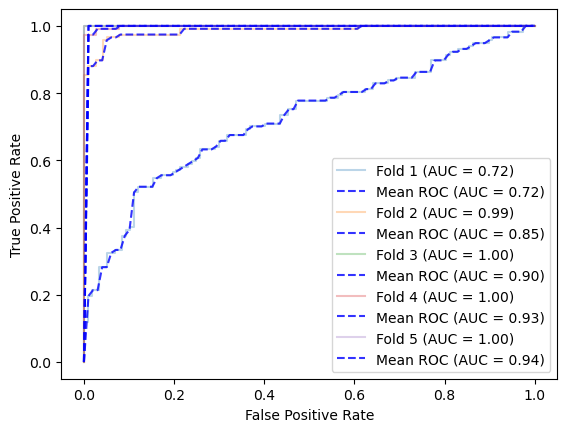

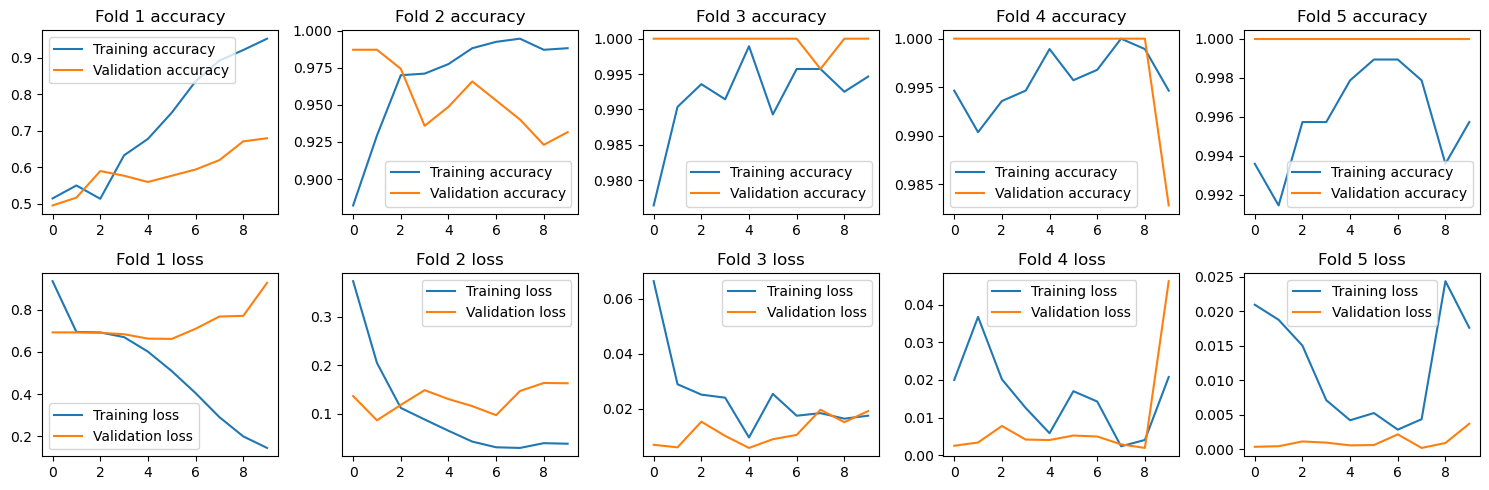

In [109]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
X=np.load("E:/ADHD_EXP/unni/upsampled_ICA+DL_threshold_0.1178_power_8.npy")
Y=np.load("E:/ADHD_EXP/unni/upsampled_labels_1168.npy")
X=np.reshape(X,(X.shape[0],X.shape[1]*X.shape[2]))
# Preprocess the data as needed, such as normalization or rescaling
input_shape = (X.shape[1], 1)
# Define the model architecture
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(X.shape[1], 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
# Define the k-fold cross-validation
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
# Define the lists to store the results
auc_scores = []
precisions=[]
sensitivities=[]
specificities=[]
accuracies=[]
tprs=[]

acc_scores = []
val_acc_scores = []
loss_scores = []
val_loss_scores = []

mean_fpr = np.linspace(0, 1, 100)

# Train and evaluate the model using k-fold cross-validation and ROC curves
for fold, (train_idx, val_idx) in enumerate(skf.split(X, Y)):
    print(f"Fold {fold + 1}/{k}")
    
    # Split the data into training and validation sets
    X_train, y_train = X[train_idx], Y[train_idx]
    X_val, y_val = X[val_idx], Y[val_idx]
    
    # Reshape the data for the Conv1D layer
    X_train = np.expand_dims(X_train, axis=-1)
    X_val = np.expand_dims(X_val, axis=-1)
    
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()
    history=model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_val, y_val))
    acc_scores.append(history.history['accuracy'])
    val_acc_scores.append(history.history['val_accuracy'])
    loss_scores.append(history.history['loss'])
    val_loss_scores.append(history.history['val_loss'])
    
    # Calculate the predicted probabilities and ROC curve
    y_pred_prob = model.predict(X_val)
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    auc_score = roc_auc_score(y_val, y_pred_prob)
    auc_scores.append(auc_score)
    
    # Interpolate the ROC curve to the mean FPR
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    y_pred = np.where(y_pred_prob > 0.5, 1, 0)
    conf_matrix = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    precision = tp / (tp + fp)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    tprs.append(tpr)
    #aucs.append(roc_auc)
    precisions.append(precision)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    accuracies.append(accuracy)
    # Plot the ROC curve
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold + 1} (AUC = {auc_score:.2f})")
    plt.plot(mean_fpr, interp_tpr, alpha=0.8, label=f"Mean ROC (AUC = {np.mean(auc_scores):.2f})", color='b', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')

#mean_tpr = np.mean(tprs, axis=0)
#std_tpr = np.std(tprs, axis=0)
mean_precision = np.mean(precisions)
std_precision = np.std(precisions)
mean_sensitivity = np.mean(sensitivities)
std_sensitivity = np.std(sensitivities)
mean_specificity = np.mean(specificity)
std_specificity = np.std(specificity)
mean_accuracy  = np.mean(accuracies)
std_accuracy  = np.std(accuracies)
    # Print the average AUC score over all folds
print(f"Mean AUC score: {np.mean(auc_scores):.2f}")
print("Precision : ", mean_precision, '(+/-)' , std_precision)
print("Sensitivity : ",mean_sensitivity, '(+/-)' , std_sensitivity)
print("Specificity : ",mean_specificity, '(+/-)' , std_specificity)
print("Accuracy : ",mean_accuracy, '(+/-)' , std_accuracy)
# Save the plot
plt.savefig('roc_curve.png')

fig, axs = plt.subplots(2, k, figsize=(15, 5))
for i in range(k):
    axs[0,i].plot(acc_scores[i], label='Training accuracy')
    axs[0,i].plot(val_acc_scores[i], label='Validation accuracy')
    axs[0,i].set_title(f'Fold {i+1} accuracy')
    axs[0,i].legend()
    axs[1,i].plot(loss_scores[i], label='Training loss')
    axs[1,i].plot(val_loss_scores[i], label='Validation loss')
    axs[1,i].set_title(f'Fold {i+1} loss')
    axs[1,i].legend()

plt.tight_layout()
plt.show()